In [4]:
import glob
import os
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import trackpy as tp
from sklearn.linear_model import LinearRegression

%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

In [5]:
# Loads tracks

tracks_path = r"/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_4_conf561_merged_spots_tracks.csv"
tracks = pd.read_csv(tracks_path)
tracks.head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0,1.0_0.0,361
1,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444,1,1.0_1.0,161
2,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0,1.0_0.0,361
3,1,1,225.587597,691.852900,3612.544331,3790.500000,2.326372,2.053595,898.027778,2,1.0_2.0,413
4,1,1,222.966845,709.648257,3948.350167,8244.582731,1.345105,1.342684,1231.333333,1,1.0_1.0,161


In [85]:
# Load all files from one folder

D21_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis'
D21_path = os.path.join(D21_dir,'*.csv') 
D21_files = glob.glob(D21_path)

In [86]:
D21_files

['/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_4_conf561_merged_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_9_conf561_merged_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_18_conf561_merged_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_15_conf561_merged_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_10_conf561_merged_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_16_conf561_merged_spots_tracks.csv',
 '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Develop_mobility_analysis/100tp_561-100-50ms-1000g_8_conf561_merged_spots_t

In [157]:
# Read csv files into list

D21_all_files = []

for file in D21_files:
    table = pd.read_csv(file)
    D21_all_files.append(table)

D21_all_files[0].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0,1.0_0.0,361
1,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444,1,1.0_1.0,161
2,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0,1.0_0.0,361
3,1,1,225.587597,691.852900,3612.544331,3790.500000,2.326372,2.053595,898.027778,2,1.0_2.0,413
4,1,1,222.966845,709.648257,3948.350167,8244.582731,1.345105,1.342684,1231.333333,1,1.0_1.0,161


In [147]:
def create_unique_track_id(row: pd.Series, file_identifier: str) -> str:
    """
    Function to create unique track-ids for all tracks of all ROIs per image
    by combining roi_id, particle number, and file information.
    """
    return f"{file_identifier}_{row['roi_id']}_{row['particle']}"

In [149]:
def uniqueid(tracks):
    tracks['unique_id'] = tracks['file_roi_particle']
    track_ids = tracks['file_roi_particle'].unique()
    tracks['unique_id'] = tracks['unique_id'].replace(to_replace=track_ids, value=np.random.permutation(len(track_ids)))

    return tracks

In [153]:
def split_table_by_ROI_and_track(df):
    """
    Splits each spots file into seperate dfs by roi_id and track_id, so that spots can be sorted and filtered by frame' 
    """
    df = df.groupby(["roi_id","track_id"], sort = False, as_index = False)
    
    return df

In [158]:
D21_all_files_unique = []

for i, df in enumerate(D21_all_files):

    # Apply unique track IDs using the create_track_id function
    df['file_number'] = i
    df['file_roi_particle'] = df.apply(lambda row: create_unique_track_id(row, i), axis=1)
   
    # Append the DataFrame to the list
    D21_all_files_unique.append(df)

D21_all_files_unique[6].head()


,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
0,0,1,226.859197,305.321186,4301.385237,10016.922256,1.298940,1.198511,1168.694444,2,1.0_2.0,224,6,6_1_2
1,0,1,212.969244,301.630417,4365.325607,5207.984864,1.747449,1.403531,1030.222222,3,1.0_3.0,232,6,6_1_3
2,1,1,212.535809,302.191006,6086.196131,3931.500000,1.448537,0.372889,956.527778,3,1.0_3.0,232,6,6_1_3
3,1,1,230.449259,313.406879,399.620372,6072.430690,2.905602,3.000000,662.138889,4,1.0_4.0,211,6,6_1_4
4,1,1,226.844994,306.449051,4218.609641,4273.000000,1.970122,1.588086,895.750000,2,1.0_2.0,224,6,6_1_2


In [159]:
# Splits tables into seperate dfs by track_id

singletracks_all = []

for tracks in D21_all_files:
    singletracks = [j for i,j in split_table_by_ROI_and_track(tracks)]
    singletracks_all.append(singletracks)

singletracks_all[2][1].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
1,0,1,261.447187,724.663492,2889.795669,1826.500000,1.179245,0.347080,472.361111,1,1.0_1.0,254,2,2_1_1
4,1,1,258.613368,723.280496,1652.275885,1706.000000,2.550774,2.079038,367.055556,1,1.0_1.0,254,2,2_1_1
5,2,1,256.515271,721.489592,2820.446625,1813.500000,1.131987,0.385563,399.333333,1,1.0_1.0,254,2,2_1_1
8,3,1,253.557940,720.395004,1511.032088,4411.844326,1.869471,1.648554,544.750000,1,1.0_1.0,254,2,2_1_1
10,4,1,254.586847,719.103279,888.055558,2955.691228,3.000000,2.800186,398.694444,1,1.0_1.0,254,2,2_1_1


In [160]:
# Sorts tracks by "frame" and saves all tracks in a list

singletracks_all_sorted = []
        
for file in singletracks_all:
    for df in file:
        df["frame"] = df["frame"].astype(int) # Is necessary for correct sorting
        df = df.sort_values(by="frame").reset_index(drop=True)
        singletracks_all_sorted.append(df)

singletracks_all_sorted[0].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0,1.0_0.0,361,0,0_1_0
1,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0,1.0_0.0,361,0,0_1_0
2,2,1,240.328955,700.741154,5583.280788,6133.569507,1.439603,1.193348,1110.166667,0,1.0_0.0,361,0,0_1_0
3,4,1,242.851238,698.722484,5135.884129,6957.468183,1.261824,1.509359,1119.916667,0,1.0_0.0,361,0,0_1_0
4,5,1,242.618622,699.444406,4381.751535,8336.041280,1.491042,1.213166,1067.305556,0,1.0_0.0,361,0,0_1_0


In [161]:
print(type(singletracks_all))
print(len(singletracks_all))
print(type(singletracks_all_sorted))
print(len(singletracks_all_sorted))
print(type(singletracks_all[0]))
print(type(singletracks_all_sorted[0]))

<class 'list'>
7
<class 'list'>
1923
<class 'list'>
<class 'pandas.core.frame.DataFrame'>


In [162]:
D21_all_tracks = pd.concat(singletracks_all_sorted)
type(D21_all_tracks)

pandas.core.frame.DataFrame

In [163]:
D21_all_tracks = uniqueid(D21_all_tracks)

In [164]:
D21_all_tracks.head(20)

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id,file_number,file_roi_particle
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0,1.0_0.0,765,0,0_1_0
1,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0,1.0_0.0,765,0,0_1_0
2,2,1,240.328955,700.741154,5583.280788,6133.569507,1.439603,1.193348,1110.166667,0,1.0_0.0,765,0,0_1_0
3,4,1,242.851238,698.722484,5135.884129,6957.468183,1.261824,1.509359,1119.916667,0,1.0_0.0,765,0,0_1_0
4,5,1,242.618622,699.444406,4381.751535,8336.041280,1.491042,1.213166,1067.305556,0,1.0_0.0,765,0,0_1_0
5,6,1,242.954435,699.535816,5005.973955,7306.263108,1.382985,1.129199,1150.888889,0,1.0_0.0,765,0,0_1_0
6,7,1,242.389122,700.644091,4967.256959,7272.873050,1.144109,1.315427,1095.805556,0,1.0_0.0,765,0,0_1_0
0,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444,1,1.0_1.0,905,0,0_1_1
1,1,1,222.966845,709.648257,3948.350167,8244.582731,1.345105,1.342684,1231.333333,1,1.0_1.0,905,0,0_1_1
2,2,1,223.240643,708.248292,3843.506164,6778.113953,1.673037,1.371738,973.361111,1,1.0_1.0,905,0,0_1_1


In [104]:
# Defines function to calculate time-averaged MSD(tamsd) for a single track in a given ROI

def calculate_single_tamsd(
    single_traj: pd.DataFrame, min_length: int = 10, min_points: int = 1
):
    """Calculates time-averaged MSDs of one track in a given ROI.
    
    Inputs: 
        df containing coordintes of one trajectory in an ROI, sorted by frame.
        min_length: minimum length of trajectory.
        min_points: minimum number of points to consider to calculate tamsd.
        
    Return:
        results: pd.DataFrame containing lags and time-averaged MSDs of a given track.
    """
    
    # Calculates pair-wise differences between all timepoints in the trajectory and stores it in a matrix
    tvalues = single_traj["frame"].values
    tvalues = tvalues[:, None] - tvalues
  
    # List of lags
    lags = np.arange(len(single_traj)) + 1
    
    final_lags = []
    tamsd = []
    
    # Loop over lags
    for lag in lags:
        # Find indices of pairs of timepoints with lag equal to the selected lag
        x,y = np.where(tvalues == lag)
        
        single_traj["x"] = single_traj["x"].astype(float)
        single_traj["y"] = single_traj["y"].astype(float)
        
        if len(single_traj) < min_length:
            continue
        
        if len(x) < min_points:
            continue
        
        tmp_tamsd = np.mean(
            
                np.square(
                single_traj.iloc[x][["x","y"]].values
                -single_traj.iloc[y][["x","y"]].values
                )
            
        )
        
        final_lags.append(lag)
        tamsd.append(tmp_tamsd)
    
    df = pd.DataFrame({"lags": final_lags, "tamsd": tamsd})
    
    return df    

In [105]:
# Calculates time-averaged MSD(tamsd) for a single track in a given ROI

tamsd_singletrack = calculate_single_tamsd(singletracks_all_sorted[5])
print(tamsd_singletrack)

    lags      tamsd
0      1   0.898290
1      2   1.708033
2      3   2.541214
3      4   2.605851
4      5   3.584329
5      6   3.676541
6      7   3.791488
7      8   3.094006
8      9   3.536085
9     10   2.642087
10    11   2.969788
11    12   3.046364
12    13   4.266454
13    14   5.274210
14    15   6.588555
15    16   8.626724
16    17   9.846719
17    18  10.426632
18    19  11.604409
19    20  14.678411
20    21  17.500801
21    22  13.030325


To get correct amount of lags, +1 needs to be added to the np.arange(len(single_traj)), otherwise the first lag would be 0. 
Specific example where one track contains 24 time points: The tvalues, meaning the differences between time points, range from +/- 1 to +/- 23, excluding (!) the value 24. Therefore when finding values where tvalues == lags, the value 24, which is an artifact of the len(single_traj) calculation, is excluded and the remaining values range from 1 to 23, which corresponds exactly to the amount of lags present.

In [106]:
# Calculates the tamsd for all tracks seperately and saves them in a list

tamsd_seperate_tracks = []

for track in singletracks_all_sorted:
    tamsd = calculate_single_tamsd(track)
    tamsd_seperate_tracks.append(tamsd)

print(tamsd_seperate_tracks[5])

    lags      tamsd
0      1   0.898290
1      2   1.708033
2      3   2.541214
3      4   2.605851
4      5   3.584329
5      6   3.676541
6      7   3.791488
7      8   3.094006
8      9   3.536085
9     10   2.642087
10    11   2.969788
11    12   3.046364
12    13   4.266454
13    14   5.274210
14    15   6.588555
15    16   8.626724
16    17   9.846719
17    18  10.426632
18    19  11.604409
19    20  14.678411
20    21  17.500801
21    22  13.030325


In [107]:
len(tamsd_seperate_tracks)

1923

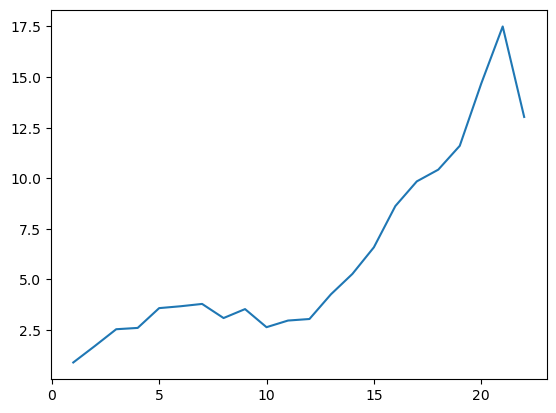

In [108]:
fig, ax = plt.subplots()
ax.plot(tamsd_singletrack["lags"],tamsd_singletrack["tamsd"])

In [165]:
# Calculates time-averaged MSD (tamsd) for a all tracks in a given ROI

def calculate_all_tamsd(
    all_traj: pd.DataFrame, min_points: int = 1, min_length: int = 5, radial: bool = False
):
    """Calculates time-averaged MSDs of all tracks in a given ROI.
    
    Inputs: 
        df containing coordintes of every trajectory in an ROI, sorted by "frame".
        min_points: minimum number of points to consider time-averaged MSD.
        min_length: minimum length of trajectory accepted.
        
    Return:
        results: pd.DataFrame containing all time-averaged MSDs of a give ROI.
    """
    
    # Output results
    results = pd.DataFrame()
    
    # Loop for all tracks
    for track_id in all_traj["unique_id"].unique():
        
        # Extract single trajectories and sort by frame
        single_traj = all_traj[all_traj["unique_id"] == track_id].copy().sort_values(by="frame")
        
        # Filter out short tracks
        if len(single_traj) < min_length:
            continue
            
        df_tmp = calculate_single_tamsd(
            single_traj, min_points = min_points
        )
        df_tmp["track_id"] = track_id
        results = pd.concat([results, df_tmp])
        
    return results

In [166]:
# Calculates time-averaged MSD(tamsd) for all tracks

tamsd_D21_all_tracks = calculate_all_tamsd(D21_all_tracks)
tamsd_D21_all_tracks.head()

,lags,tamsd,track_id
0,1.0,0.807069,905
1,2.0,2.040402,905
2,3.0,4.032671,905
3,4.0,6.790539,905
4,5.0,10.057268,905


<Axes: xlabel='lags', ylabel='tamsd'>

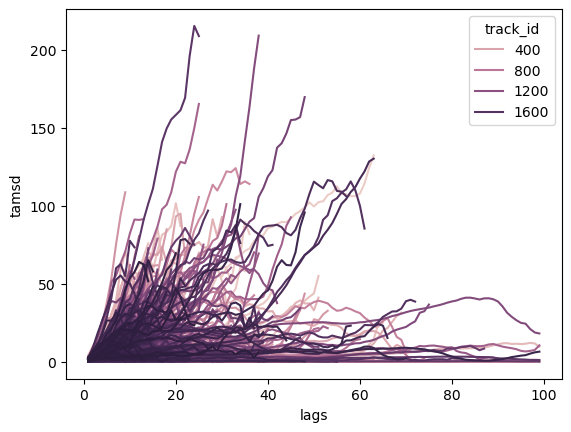

In [167]:
# Plots tamsds of all tracks

sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D21_all_tracks)

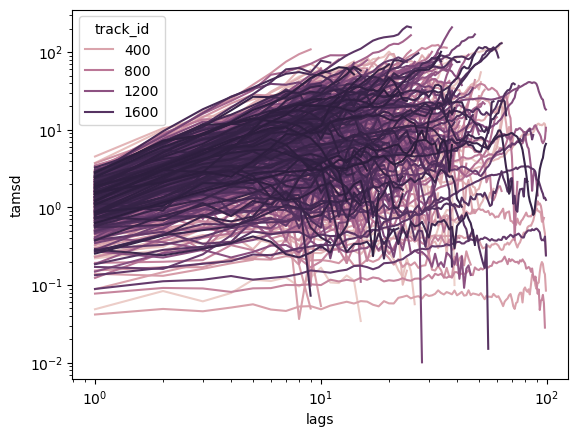

In [169]:
# Plots tamsds of all ROIs in log/log

sns.lineplot(x="lags", y="tamsd",
             hue="track_id",
             data=tamsd_D21_all_tracks)
plt.yscale("log")
plt.xscale("log")

In [171]:
len(D21_all_tracks["unique_id"].unique())

1923

## Plot distributions of D (inst. diffusion coefficient) and alpha (slope, anomalous exponent)

Here I do a linear fit on the single MSDs for each trajectory based on the initial 5 points (numPoints) of the MSD for each trajectory (in log, log). So then the slope of the fitted curve is the anomalous exponent and the intersect can be interpreted as the instantaneiys diffusion coefficient (under some circumstances). Ask physicists ;)

In [172]:
### To do a linear fit on the log(dt), log(MSD) curve and define alpha and D

def get_D_alpha(traj, min_length=10, numPoints=5):
    if traj.shape[0]<min_length:
        return np.nan, np.nan
    model = LinearRegression()
    x = np.log10(traj.loc[:, "lags"])
    y = np.log10(traj.loc[:, "tamsd"])
    #print(x.to_numpy().reshape(-1,1)[:numPoints], y.to_numpy()[:numPoints], sampleWeight.to_numpy()[:numPoints])
    model.fit(x.to_numpy().reshape(-1,1)[:numPoints], y.to_numpy()[:numPoints])
    return model.intercept_.round(4), model.coef_.round(4)[0]

In [41]:
D_alpha = get_D_alpha(tamsd_singletrack)
D_alpha

(-0.0316, 0.8268)

In [173]:
# How to calcualte D and alpha from single track in entire tamsd file

In [58]:
D_alpha_rows = []

for track in tamsd_seperate_tracks:
    D, alpha = get_D_alpha(track)
    D_alpha_rows.append({"D": D, "alpha": alpha})

D_alpha_alltracks = pd.DataFrame(D_alpha_rows)

print(D_alpha_alltracks)

          D   alpha
0       NaN     NaN
1   -0.1224  1.5721
2       NaN     NaN
3       NaN     NaN
4   -0.3387  1.0720
..      ...     ...
437     NaN     NaN
438     NaN     NaN
439 -0.0288  0.6979
440     NaN     NaN
441     NaN     NaN

[442 rows x 2 columns]


In [53]:
D_alpha_alltracks = pd.DataFrame(columns=["D", "alpha"])

for track in tamsd_seperate_tracks:
    result = get_D_alpha(track)  # Store the result
    print(result)  # Print the result to check its format
    # D_alpha_alltracks.append({"D": result[0], "alpha": result[1]}, ignore_index=True)

print(D_alpha_alltracks)

(nan, nan)
(-0.1224, 1.5721)
(nan, nan)
(nan, nan)
(-0.3387, 1.072)
(-0.0316, 0.8268)
(nan, nan)
(-0.0446, 0.5392)
(nan, nan)
(nan, nan)
(0.1921, 1.1525)
(nan, nan)
(-0.0702, 1.255)
(0.1399, 0.403)
(-0.0393, 0.7673)
(nan, nan)
(-0.0291, 0.4203)
(nan, nan)
(-0.5341, 0.5415)
(-0.1679, 0.8318)
(nan, nan)
(0.2036, 0.1865)
(0.0043, 0.8312)
(nan, nan)
(nan, nan)
(-0.1272, 0.678)
(nan, nan)
(0.0756, 0.8118)
(-0.2395, 0.8137)
(nan, nan)
(nan, nan)
(-0.2906, 1.5697)
(-0.143, 0.5833)
(-0.3501, 0.6007)
(nan, nan)
(nan, nan)
(nan, nan)
(0.0343, 0.1771)
(nan, nan)
(-0.2762, 0.5319)
(0.1495, 0.9691)
(nan, nan)
(nan, nan)
(nan, nan)
(nan, nan)
(nan, nan)
(-0.6956, 1.0266)
(nan, nan)
(0.1686, 1.2757)
(nan, nan)
(nan, nan)
(nan, nan)
(-0.0176, 0.9035)
(0.1919, 1.2609)
(nan, nan)
(nan, nan)
(nan, nan)
(nan, nan)
(0.3658, 0.6339)
(0.4338, 1.3588)
(-0.5486, 1.1031)
(nan, nan)
(0.1603, 0.9651)
(nan, nan)
(nan, nan)
(0.4831, 1.0467)
(nan, nan)
(nan, nan)
(0.0414, 0.6362)
(0.3737, 0.6843)
(nan, nan)
(0.2942,

In [59]:
D_alpha_alltracks_filtered = D_alpha_alltracks.dropna(how='all')
print(D_alpha_alltracks_filtered)

          D   alpha
1   -0.1224  1.5721
4   -0.3387  1.0720
5   -0.0316  0.8268
7   -0.0446  0.5392
10   0.1921  1.1525
..      ...     ...
431 -0.0778  0.4520
433 -0.1857  0.4223
434 -0.2747  0.8656
435  0.2339  0.9245
439 -0.0288  0.6979

[173 rows x 2 columns]


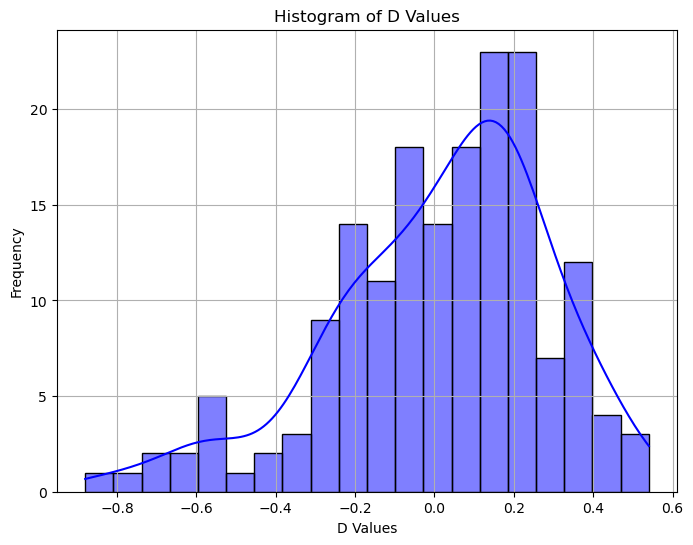

In [62]:
# Plot histogram for 'D'
plt.figure(figsize=(8, 6))
sns.histplot(data=D_alpha_alltracks['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('D Values')
plt.ylabel('Frequency')
plt.title('Histogram of D Values')
plt.grid(True)
plt.show()

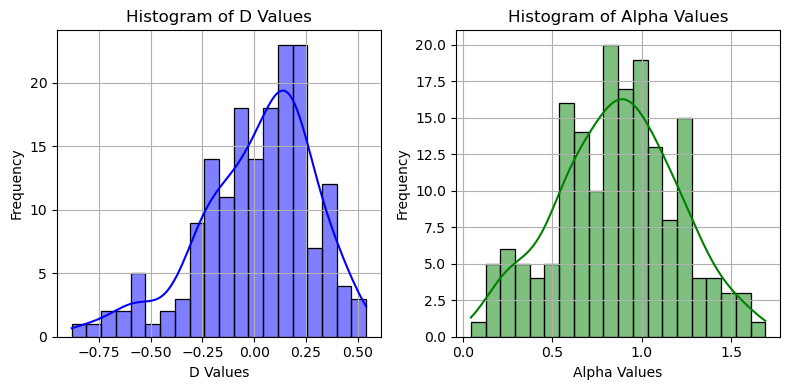

In [67]:
# Create a figure with two subplots side by side
plt.figure(figsize=(8, 4))

# Plot histogram for 'D'
plt.subplot(1, 2, 1)
sns.histplot(data=D_alpha_alltracks['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('D Values')
plt.ylabel('Frequency')
plt.title('Histogram of D Values')
plt.grid(True)

# Plot histogram for 'alpha'
plt.subplot(1, 2, 2)
sns.histplot(data=D_alpha_alltracks['alpha'].dropna(), bins=20, color='green', kde=True)
plt.xlabel('Alpha Values')
plt.ylabel('Frequency')
plt.title('Histogram of Alpha Values')
plt.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Calculate jumps

Here I take all the long trajectories (can be set to desired length in the previous section) and calculate all the jumps (so distances travelled for a specific dt) and plot the boxplots for all found displacement given a certain dt. You could also do distributions for each dt (I gave it a try).

In [82]:
singletracks_sorted[5].head(20)

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track_id,unique_id
0,6,1,237.309924,702.166670,3221.557168,3394.000000,2.376835,2.397742,726.194444,6,1.0_6.0,51
1,8,1,239.088044,700.076245,3555.952169,3603.000000,1.894338,3.000000,792.194444,6,1.0_6.0,51
2,9,1,240.047145,698.638488,3729.735975,3853.969940,1.806374,2.245079,912.555556,6,1.0_6.0,51
3,10,1,239.793678,697.949750,2460.830847,4291.945231,2.546687,2.460488,790.416667,6,1.0_6.0,51
4,11,1,239.141818,695.242604,3246.109242,3394.000000,1.813642,1.708155,733.166667,6,1.0_6.0,51
5,12,1,239.395250,695.242520,3642.135332,3663.000000,1.870102,1.543405,762.805556,6,1.0_6.0,51
6,13,1,238.754871,696.468068,3658.767340,3629.500000,1.843813,1.761709,850.111111,6,1.0_6.0,51
7,14,1,238.847329,697.684833,3636.201869,3862.638129,2.199369,1.694802,827.138889,6,1.0_6.0,51
8,15,1,238.614839,695.632937,3639.486024,4016.518260,1.653177,1.403643,820.083333,6,1.0_6.0,51
9,16,1,238.738875,696.761178,3139.565219,3888.279185,1.946076,1.627567,824.583333,6,1.0_6.0,51


In [79]:
# Calculate single jumps from the trajectories

def calculate_jump(single_traj, axis=None):
    jumps = []
    
    tvalues = single_traj["frame"].values
    tvalues = tvalues[:, None] - tvalues

    # list of lags
    lags = np.arange(10,100,10)


    # Loop over lags
    for lag in lags:
        # find indexes of pairs of timepoints with lag equal to the selected lag
        x, y = np.where(tvalues == lag)
                
        if axis is None:
            tmp = pd.DataFrame({"jumps":np.sum(
                    np.square(
                        single_traj.iloc[x][["x", "y"]].values
                        - single_traj.iloc[y][["x", "y"]].values
                    ),
                    axis=1,
                ), "frame":single_traj.iloc[y]["frame"].values})
        elif axis in ["x", "y"]:
            tmp = pd.DataFrame({"jumps":single_traj.iloc[x][axis].values - single_traj.iloc[y][axis].values, 
                                    "frame":single_traj.iloc[y]["frame"].values})
        else:
            raise ValueError(f"axis must be in ['x', 'y'] or none, but provided {axis}")
                            
        #tmp = pd.DataFrame(tmp_jumps)
        #tmp.columns = ["jumps"]
        tmp["deltat"] = lag
        jumps.append(tmp)


    return pd.concat(jumps)

In [80]:
jumps = calculate_jump(single_traj=singletracks_sorted[5])
jumps

,jumps,frame,deltat
0,31.261247,6,10
1,3.177242,8,10
2,3.324287,9,10
3,0.186307,10,10
4,1.779448,11,10
5,5.284105,12,10
6,1.440077,13,10
7,4.862657,14,10
8,3.470116,15,10
9,3.001801,16,10


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


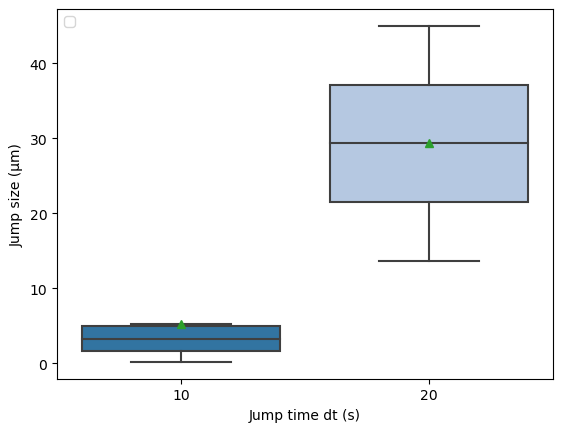

In [84]:
sns.boxplot(data=jumps, x="deltat", y="jumps", fliersize=0, palette="tab20",showmeans=True)
plt.xlabel("Jump time dt (s)")
plt.ylabel("Jump size (µm)")
plt.legend(loc="upper left")
plt.show()

### Comparing msd function to trackpy function

In [19]:
# MSD function from trackpy comparison

tp_imsd = tp.imsd(singletracks[5], 0.134, 20)
tp_imsd

,6
lag time [s],
0.05,0.032259
0.10,0.061339
0.15,0.091260
0.20,0.093581
0.25,0.128720
0.30,0.132032
0.35,0.136160
0.40,0.111112
0.45,0.126988


<Axes: xlabel='lags', ylabel='tamsd'>

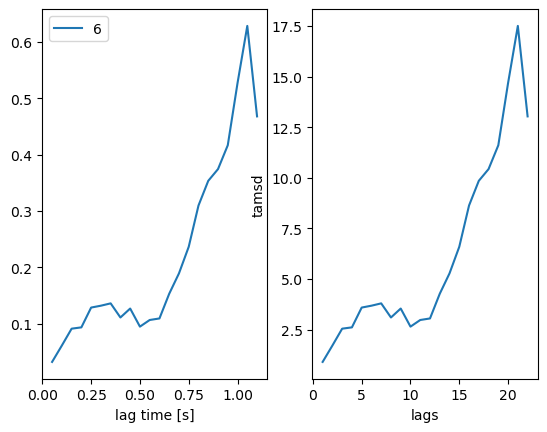

In [20]:
# Compares trackpy's MSD function with Pia's - they do the same
fig, ax = plt.subplots(1,2)
sns.lineplot(data=tp_imsd, ax=ax[0])
sns.lineplot(x="lags", y="tamsd", data=tamsd_singletrack, ax=ax[1])